In [99]:
import yfinance as yf
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [101]:
# Extracción de precios historicos en un rango determinad
disney = yf.download(tickers = 'DIS', start = "2023-01-01", end = "2023-04-01", rounding = True)
disney

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,DIS,DIS,DIS,DIS,DIS
Date,,,,,
2023-01-03,86.92,87.90,85.81,86.93,14997100
2023-01-04,89.86,90.62,87.30,87.93,14957200
2023-01-05,89.81,90.35,88.43,89.55,11622600
2023-01-06,91.76,92.51,89.22,90.53,9828100
2023-01-09,92.59,93.50,91.30,92.26,11675800
...,...,...,...,...,...
2023-03-27,93.42,93.81,92.21,92.60,7487900
2023-03-28,92.64,93.79,92.41,93.31,5426100


In [103]:
# Unimos los nombres del indice multiple para fines practicos 
disney.columns = [f'{col[0]}_{col[1]}' for col in disney.columns]
print(disney.columns)

Index(['Close_DIS', 'High_DIS', 'Low_DIS', 'Open_DIS', 'Volume_DIS'], dtype='str')


In [105]:
# Extraemos solo la columna de cierre
serie_disney = disney['Close_DIS']
serie_disney

Date
2023-01-03    86.92
2023-01-04    89.86
2023-01-05    89.81
2023-01-06    91.76
2023-01-09    92.59
              ...  
2023-03-27    93.42
2023-03-28    92.64
2023-03-29    94.64
2023-03-30    95.84
2023-03-31    97.83
Name: Close_DIS, Length: 62, dtype: float64

In [107]:
import numpy as np

# Calculamos los modelos auto-regresivos AR(p)
disney['Returns'] = np.log(disney['Close_DIS'] / disney['Close_DIS'].shift(1))
disney.dropna(inplace=True) # Eliminamos el primer valor nulo

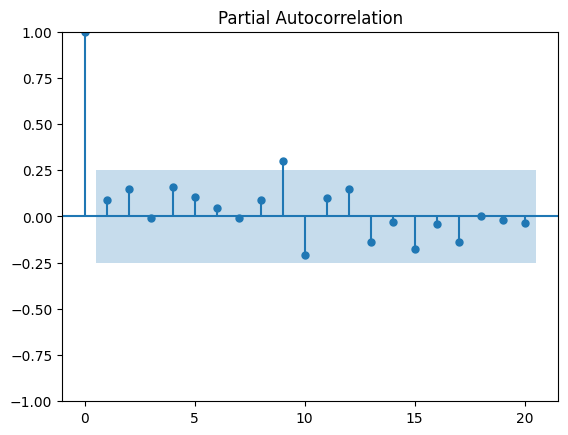

In [109]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Graficamos PACF para identificar p
plot_pacf(disney['Returns'], lags=20)
plt.show()

In [111]:
from statsmodels.tsa.ar_model import AutoReg

# Ajustamos un modelo AR(1)
modelo = AutoReg(disney['Returns'], lags=1)
resultado = modelo.fit()

# Ver el resumen estadístico
print(resultado.summary())

                            AutoReg Model Results                             
Dep. Variable:                Returns   No. Observations:                   61
Model:                     AutoReg(1)   Log Likelihood                 161.263
Method:               Conditional MLE   S.D. of innovations              0.016
Date:                Sun, 05 Apr 2026   AIC                           -316.525
Time:                        13:07:03   BIC                           -310.242
Sample:                             1   HQIC                          -314.068
                                   61                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.002      0.595      0.552      -0.003       0.005
Returns.L1     0.0902      0.126      0.715      0.475      -0.157       0.337
                                    Roots           

In [113]:
# Definimos la base de entrenamiento y prueba
serie_disney.index = pd.to_datetime(serie_disney.index)
len_train = int(len(serie_disney) * 0.7)
len_train

43

In [115]:
len_test = int(len(disney) * 0.3)
len_test

18

In [117]:
train = serie_disney[0:len_train]
train

Date
2023-01-03     86.92
2023-01-04     89.86
2023-01-05     89.81
2023-01-06     91.76
2023-01-09     92.59
2023-01-10     93.36
2023-01-11     94.11
2023-01-12     97.51
2023-01-13     97.11
2023-01-17     97.61
2023-01-18     96.76
2023-01-19     96.80
2023-01-20    101.10
2023-01-23    103.26
2023-01-24    103.56
2023-01-25    105.63
2023-01-26    107.18
2023-01-27    107.02
2023-01-30    105.11
2023-01-31    105.99
2023-02-01    106.87
2023-02-02    110.61
2023-02-03    108.16
2023-02-06    107.34
2023-02-07    109.06
2023-02-08    109.21
2023-02-09    107.82
2023-02-10    105.57
2023-02-13    105.18
2023-02-14    105.18
2023-02-15    106.73
2023-02-16    103.40
2023-02-17    102.80
2023-02-21     99.74
2023-02-22     99.34
2023-02-23     99.39
2023-02-24     97.99
2023-02-27     98.14
2023-02-28     97.32
2023-03-01     96.27
2023-03-02     96.64
2023-03-03     98.81
2023-03-06     98.34
Name: Close_DIS, dtype: float64

In [119]:
test = serie_disney[len_train:]
test

Date
2023-03-07    96.78
2023-03-08    97.02
2023-03-09    93.93
2023-03-10    91.42
2023-03-13    90.47
2023-03-14    91.21
2023-03-15    90.96
2023-03-16    92.12
2023-03-17    91.06
2023-03-20    92.05
2023-03-21    94.32
2023-03-22    92.72
2023-03-23    93.63
2023-03-24    91.92
2023-03-27    93.42
2023-03-28    92.64
2023-03-29    94.64
2023-03-30    95.84
2023-03-31    97.83
Name: Close_DIS, dtype: float64

[ 1.00000000e+00  8.93602220e-01  8.05090982e-01  7.06831403e-01
  6.22029149e-01  5.25269486e-01  4.15453726e-01  3.00137624e-01
  2.19427767e-01  1.20856207e-01  4.15433478e-04 -1.11297807e-01
 -2.28954743e-01 -3.03361876e-01 -3.62106059e-01 -4.20797328e-01
 -4.48264051e-01]


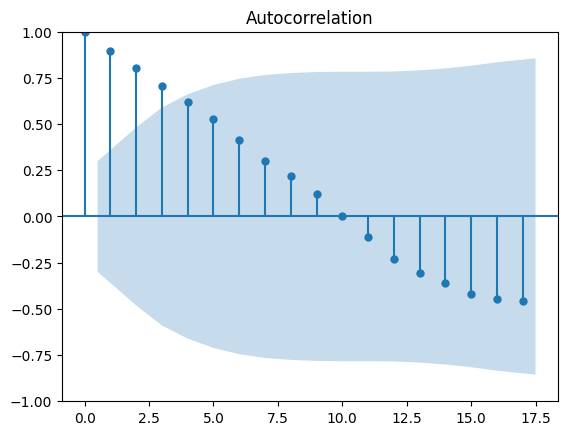

In [121]:
# Grafica de autoccorelación
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

acf_array = acf(train)
print(acf_array)

# Grafico con un nivel de confianza del 95%
plot_acf(train, alpha = 0.05)
plt.show()

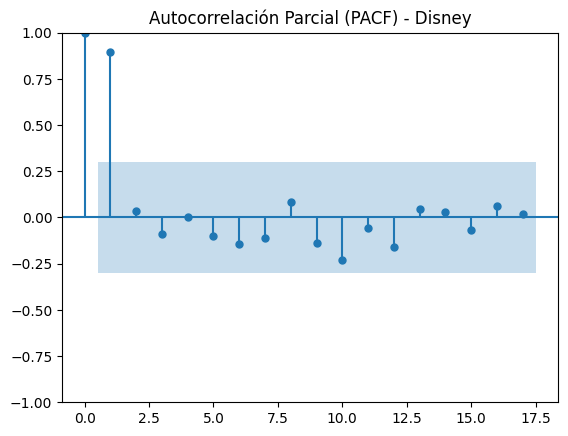

In [123]:
from statsmodels.graphics.tsaplots import plot_pacf

# Graficamos la Autocorrelación Parcial
plot_pacf(train, lags=17, alpha=0.05)
plt.title("Autocorrelación Parcial (PACF) - Disney")
plt.show()

In [125]:
# Verificamos que el índice sea de tipo datetime
train.index = pd.to_datetime(train.index)

# Asignamos la frecuencia de días hábiles ('B')
train = train.asfreq('B').ffill()

from statsmodels.tsa.arima.model import ARIMA
# Probamos distintos valores de p
for p in range(1, 4):
    model = ARIMA(train, order=(p, 0, 0)).fit()
    print(f"AR({p}): AIC={model.aic:.2f}, BIC={model.bic:.2f}")

AR(1): AIC=182.94, BIC=188.36
AR(2): AIC=184.35, BIC=191.58
AR(3): AIC=186.33, BIC=195.36


In [127]:
# Ajustamos el modelo ganador AR(1)
res_optimo = ARIMA(train, order=(1, 0, 0)).fit()

pasos = 60 

forecast_obj = res_optimo.get_forecast(steps=pasos)
pred_completa = forecast_obj.predicted_mean
int_completo = forecast_obj.conf_int(alpha=0.10)

# Seleccionamos solo el rango de Abril
pred_puntual = pred_completa.loc['2023-04-01':'2023-04-30']
intervalos_90 = int_completo.loc['2023-04-01':'2023-04-30']

print("Pronóstico puntual EXCLUSIVO para el mes de Abril:")
print(pred_puntual)

Pronóstico puntual EXCLUSIVO para el mes de Abril:
2023-04-03    97.245477
2023-04-04    97.205171
2023-04-05    97.165974
2023-04-06    97.127856
2023-04-07    97.090786
2023-04-10    97.054736
2023-04-11    97.019678
2023-04-12    96.985584
2023-04-13    96.952428
2023-04-14    96.920185
2023-04-17    96.888829
2023-04-18    96.858335
2023-04-19    96.828681
2023-04-20    96.799842
2023-04-21    96.771797
2023-04-24    96.744523
2023-04-25    96.718000
2023-04-26    96.692206
2023-04-27    96.667122
2023-04-28    96.642729
Freq: B, Name: predicted_mean, dtype: float64


In [129]:
import yfinance as yf

# Descargamos los datos reales de Abril para validar
datos_reales_abril = yf.download(tickers='DIS', start='2023-04-01', end='2023-05-01', rounding=True)['Close']
comun = datos_reales_abril.index.intersection(pred_puntual.index)
real_eval = datos_reales_abril.loc[comun]
pred_eval = pred_puntual.loc[comun]

[*********************100%***********************]  1 of 1 completed


In [131]:
# Obtenemos los indicadores comparando los valores predecidos con los datos reales
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

mae = mean_absolute_error(real_eval, pred_eval)
rmse = np.sqrt(mean_squared_error(real_eval, pred_eval))
mape = mean_absolute_percentage_error(real_eval, pred_eval)

print(f"MAE (Error Absoluto Medio): {mae:.4f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.4f}")
print(f"MAPE (Error Porcentual Absoluto Medio): {mape:.2%}")

MAE (Error Absoluto Medio): 1.0742
RMSE (Raíz del Error Cuadrático Medio): 1.3342
MAPE (Error Porcentual Absoluto Medio): 1.10%


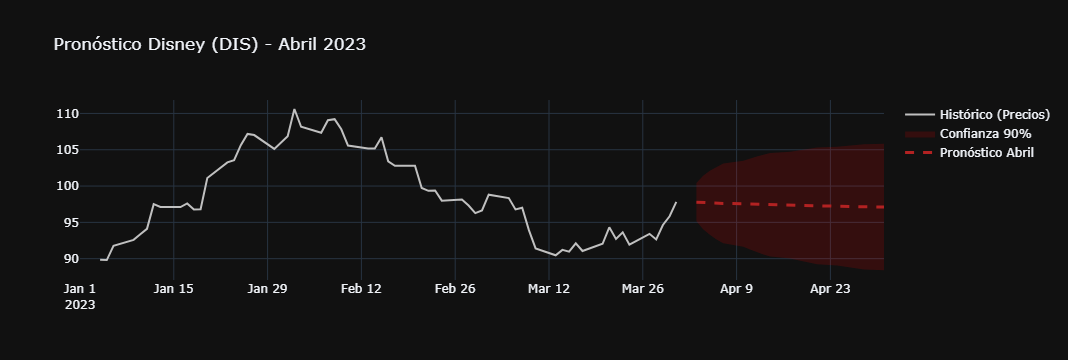

In [133]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import plotly.graph_objects as go

# Usamos todos los datos hasta el 31 de marzo
train_precios = precios_completos 

# Manejo de fechas y entrenamiento
train_precios.index = pd.to_datetime(train_precios.index)
train_precios = train_precios.resample('B').ffill().dropna()
modelo = ARIMA(train_precios, order=(1, 0, 0)).fit()

# Pronóstico para Abril
pronostico = modelo.get_forecast(steps=22)
pred_puntual = pronostico.predicted_mean
intervalos_90 = pronostico.conf_int(alpha=0.10)

fig_final = go.Figure()

# Datos Históricos (Precios)
fig_final.add_trace(go.Scatter(
    x=train_precios.index, y=train_precios,
    name='Histórico (Precios)', line=dict(color='silver', width=2)
))

# Intervalo de Confianza
fig_final.add_trace(go.Scatter(
    x=list(pred_puntual.index) + list(pred_puntual.index[::-1]),
    y=list(intervalos_90.iloc[:, 1]) + list(intervalos_90.iloc[:, 0][::-1]),
    fill='toself', fillcolor='rgba(255, 0, 0, 0.15)',
    line=dict(color='rgba(255, 255, 255, 0)'),
    name='Confianza 90%', hoverinfo="skip"
))

# Predicción
fig_final.add_trace(go.Scatter(
    x=pred_puntual.index, y=pred_puntual,
    name='Pronóstico Abril', line=dict(color='firebrick', width=3, dash='dash')
))

fig_final.update_layout(
    template='plotly_dark',
    title='Pronóstico Disney (DIS) - Abril 2023',
    xaxis_range=['2023-01-01', '2023-05-01']
)

fig_final.show()